In [1]:
import re
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd

glmsingle_url = "https://raw.githubusercontent.com/cvnlab/GLMsingle/refs/heads/main/glmsingle/hrf"
for name in ["getcanonicalhrflibrary.tsv", "gethrf.py"]:
    if not Path(name).is_file():
        urlretrieve(f"{glmsingle_url}/{name}", name)

# One HRF per column, sampled every 0.1 s
hrf_library = pd.read_table("getcanonicalhrflibrary.tsv", header=None).to_numpy()

# GLMsingle's own canonical HRF, also sampled every 0.1 s
match = re.search(r"def basichrf\(\):\s*hrf = np.asarray\((\[.*?\])\)", Path("gethrf.py").read_text(), re.S)
assert match is not None
canonical_hrf = np.array(eval(match.group(1)))
hrf_library.shape, canonical_hrf.shape

((501, 20), (490,))

In [2]:
sampling_interval = 0.1
time = np.arange(hrf_library.shape[0]) * sampling_interval
canonical_time = np.arange(canonical_hrf.shape[0]) * sampling_interval

# Scale all HRFs to a peak of one
hrf_library = hrf_library / hrf_library.max(axis=0)
canonical_hrf = canonical_hrf / canonical_hrf.max()

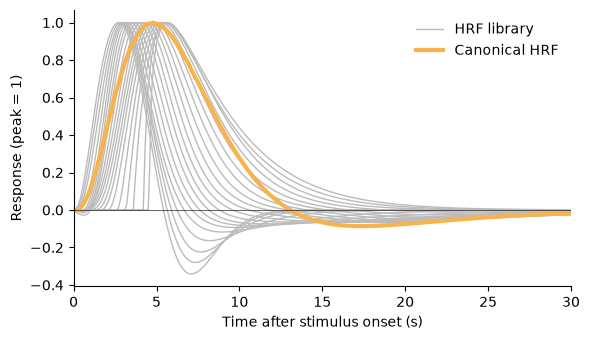

In [3]:
from matplotlib import pyplot as plt

figure, axes = plt.subplots(figsize=(6, 3.5))

axes.plot(time, hrf_library, color="#bbbbbb", linewidth=1)
axes.plot([], [], color="#bbbbbb", linewidth=1, label="HRF library")
axes.plot(canonical_time, canonical_hrf, color="#f9b34b", linewidth=3, label="Canonical HRF")

axes.axhline(0, color="#222222", linewidth=0.5)
axes.set_xlim(0, 30)
axes.set_xlabel("Time after stimulus onset (s)")
axes.set_ylabel("Response (peak = 1)")
axes.spines[["top", "right"]].set_visible(False)
axes.legend(frameon=False)

figure.tight_layout()
figure.savefig("hrf.svg")